# Connect-4 Demo: Play Against the AI

This notebook lets you play Connect-4 against either:
- **CNN** (Convolutional Neural Network)
- **Transformer** (Vision Transformer)

## Instructions
1. Run all setup cells first
2. Upload the model weights when prompted
3. Choose your opponent (CNN or Transformer)
4. Play by entering column numbers (0-6)

---

## 1. Setup and Imports

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

print(f"TensorFlow version: {tf.__version__}")
print("Setup complete!")

TensorFlow version: 2.19.0
Setup complete!


## 2. Game Engine

In [2]:
def update_board(board, color, column):
    """Place a piece in the specified column."""
    board = board.copy()
    colsum = np.sum(np.abs(board[:, column]))
    row = int(5 - colsum)

    if row >= 0:
        if color == 'plus':
            board[row, column] = 1
        else:
            board[row, column] = -1
    return board


def check_for_win(board, col):
    """Check if the last move in 'col' resulted in a win."""
    colsum = np.sum(np.abs(board[:, col]))
    row = int(6 - colsum)

    # Check all directions
    directions = [
        [(0, 1), (0, -1)],   # Horizontal
        [(1, 0), (-1, 0)],   # Vertical
        [(1, 1), (-1, -1)],  # Diagonal \
        [(1, -1), (-1, 1)]   # Diagonal /
    ]

    player = board[row, col]
    if player == 0:
        return 'nobody'

    for dir_pair in directions:
        count = 1
        for dr, dc in dir_pair:
            r, c = row + dr, col + dc
            while 0 <= r < 6 and 0 <= c < 7 and board[r, c] == player:
                count += 1
                r += dr
                c += dc
        if count >= 4:
            return 'plus' if player == 1 else 'minus'

    return 'nobody'


def find_legal(board):
    """Return list of columns that are not full."""
    return [i for i in range(7) if board[0, i] == 0]


def is_draw(board):
    """Check if the board is full (draw)."""
    return len(find_legal(board)) == 0


def board_to_nn_input(board, player):
    """
    Convert board to neural network input format.
    Always from the perspective of the current player.

    Returns: (6, 7, 2) array for CNN or (42, 2) for Transformer
    """
    if player == 'minus':
        board = board * -1

    # Channel 0: current player pieces, Channel 1: opponent pieces
    X = np.zeros((6, 7, 2), dtype=np.float32)
    X[:, :, 0] = (board == 1).astype(np.float32)   # Current player
    X[:, :, 1] = (board == -1).astype(np.float32)  # Opponent
    return X


print("Game engine loaded!")

Game engine loaded!


## 3. Board Visualization

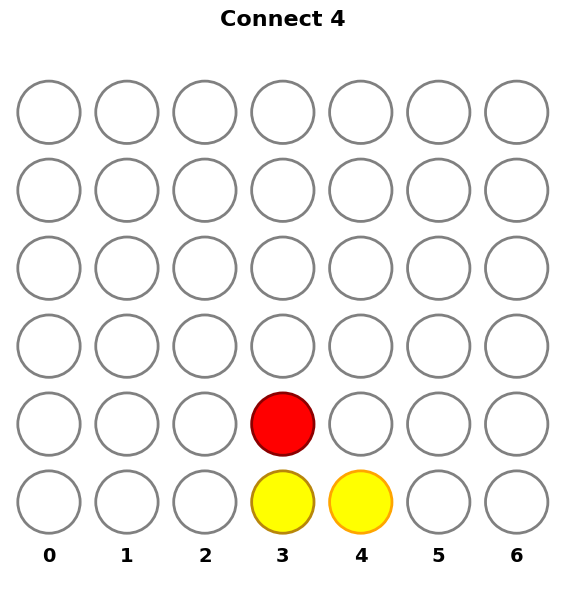

Board visualization ready!


In [3]:
def display_board(board, last_move=None):
    """Display the board with colored pieces."""
    fig, ax = plt.subplots(figsize=(7, 6))

    # Draw board background
    ax.set_facecolor('#0066cc')

    for row in range(6):
        for col in range(7):
            # Determine piece color
            if board[row, col] == 1:
                color = 'yellow'
                edge = 'orange' if (last_move == col and row == int(6 - np.sum(np.abs(board[:, col])))) else 'darkgoldenrod'
            elif board[row, col] == -1:
                color = 'red'
                edge = 'orange' if (last_move == col and row == int(6 - np.sum(np.abs(board[:, col])))) else 'darkred'
            else:
                color = 'white'
                edge = 'gray'

            circle = plt.Circle((col, 5-row), 0.4, color=color, ec=edge, linewidth=2)
            ax.add_patch(circle)

    # Column numbers
    for col in range(7):
        ax.text(col, -0.7, str(col), ha='center', va='center', fontsize=14, fontweight='bold')

    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(-1, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Connect 4', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()


def print_board_text(board):
    """Simple text representation of the board."""
    symbols = {1: 'X', -1: 'O', 0: '.'}
    print("\n  0 1 2 3 4 5 6")
    print(" " + "-" * 15)
    for row in range(6):
        print("|", end=" ")
        for col in range(7):
            print(symbols[board[row, col]], end=" ")
        print("|")
    print(" " + "-" * 15)


# Test display
test_board = np.zeros((6, 7))
test_board = update_board(test_board, 'plus', 3)
test_board = update_board(test_board, 'minus', 3)
test_board = update_board(test_board, 'plus', 4)
display_board(test_board, last_move=4)
print("Board visualization ready!")

## 4. Upload Model Weights

Upload your trained model files:
- `transformer.weights.h5` - Transformer model weights
- `cnn.h5` - CNN model (full model file)

## 5. Define Model Architectures

In [5]:
# ============ TRANSFORMER ARCHITECTURE ============

class PositionalEmbedding(layers.Layer):
    def __init__(self, num_patches, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.embedding = self.add_weight(
            shape=(1, self.num_patches, self.hidden_dim),
            initializer="random_normal",
            trainable=True,
            name="pos_embedding"
        )
        super().build(input_shape)

    def call(self, x):
        return self.embedding

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches, "hidden_dim": self.hidden_dim})
        return config


class ClassToken(layers.Layer):
    def __init__(self, hidden_dim, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim

    def build(self, input_shape):
        self.class_token = self.add_weight(
            shape=(1, 1, self.hidden_dim),
            initializer="random_normal",
            trainable=True,
            name="class_token"
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]
        class_token = tf.broadcast_to(self.class_token, [batch_size, 1, self.hidden_dim])
        return tf.concat([class_token, x], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({"hidden_dim": self.hidden_dim})
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, hidden_dim, num_heads, mlp_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads
        self.mlp_dim = mlp_dim
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.mha = layers.MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.hidden_dim // self.num_heads,
            dropout=self.dropout_rate
        )
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp_dense1 = layers.Dense(self.mlp_dim, activation="gelu")
        self.mlp_dropout1 = layers.Dropout(self.dropout_rate)
        self.mlp_dense2 = layers.Dense(self.hidden_dim)
        self.mlp_dropout2 = layers.Dropout(self.dropout_rate)
        super().build(input_shape)

    def call(self, x, training=None):
        ln1_out = self.ln1(x)
        attn_out = self.mha(ln1_out, ln1_out, training=training)
        x = x + attn_out
        ln2_out = self.ln2(x)
        mlp_out = self.mlp_dense1(ln2_out)
        mlp_out = self.mlp_dropout1(mlp_out, training=training)
        mlp_out = self.mlp_dense2(mlp_out)
        mlp_out = self.mlp_dropout2(mlp_out, training=training)
        return x + mlp_out

    def get_config(self):
        config = super().get_config()
        config.update({
            "hidden_dim": self.hidden_dim,
            "num_heads": self.num_heads,
            "mlp_dim": self.mlp_dim,
            "dropout_rate": self.dropout_rate
        })
        return config


def build_transformer(
    num_rows=6, num_cols=7, patch_features=2,
    hidden_dim=128, num_layers=6, num_heads=8,
    mlp_dim=256, dropout_rate=0.1
):
    num_patches = num_rows * num_cols

    inp = layers.Input(shape=(num_patches, patch_features), name="board_input")
    x = layers.Dense(hidden_dim, name="patch_projection")(inp)

    pos_emb = PositionalEmbedding(num_patches, hidden_dim, name="pos_embedding")(inp)
    x = layers.Add()([x, pos_emb])
    x = layers.Dropout(dropout_rate)(x)
    x = ClassToken(hidden_dim, name="class_token_layer")(x)

    for i in range(num_layers):
        x = TransformerBlock(hidden_dim, num_heads, mlp_dim, dropout_rate, name=f"transformer_block_{i}")(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="final_ln")(x)

    # Policy head
    patch_tokens = layers.Lambda(lambda t: t[:, 1:, :], name="extract_patches")(x)
    patch_tokens = layers.Reshape((num_rows, num_cols, hidden_dim), name="reshape_patches")(patch_tokens)
    col_features = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1), name="col_pooling")(patch_tokens)
    policy_hidden = layers.Dense(64, activation="relu", name="policy_dense1")(col_features)
    policy_logits = layers.Dense(1, name="policy_dense2")(policy_hidden)
    policy_logits = layers.Flatten(name="policy_flatten")(policy_logits)
    policy_output = layers.Softmax(name="policy")(policy_logits)

    # Value head
    class_token_out = layers.Lambda(lambda t: t[:, 0, :], name="extract_class")(x)
    value_hidden = layers.Dense(128, activation="relu", name="value_dense1")(class_token_out)
    value_hidden = layers.Dropout(dropout_rate)(value_hidden)
    value_hidden = layers.Dense(64, activation="relu", name="value_dense2")(value_hidden)
    value_output = layers.Dense(1, activation="tanh", name="value")(value_hidden)

    return Model(inputs=inp, outputs=[policy_output, value_output], name="Transformer")


print("Transformer architecture defined!")

Transformer architecture defined!


## 6. Load Models

In [7]:
import os

# Load Transformer
transformer_model = None
if os.path.exists('transformer.weights.h5'):
    transformer_model = build_transformer(
        hidden_dim=128,
        num_layers=6,
        num_heads=8,
        mlp_dim=256,
        dropout_rate=0.1,
    )
    transformer_model.load_weights('transformer.weights.h5')
    print("Transformer model loaded!")
else:
    print("Transformer weights not found (transformer.weights.h5)")

# Load CNN
cnn_model = None
if os.path.exists('cnn.h5'):
    cnn_model = tf.keras.models.load_model('cnn.h5', compile=False)
    print("CNN model loaded!")
else:
    print("CNN model not found (cnn.h5)")

# Summary
print("\n" + "="*40)
print("Available models:")
if transformer_model:
    print("  - Transformer")
if cnn_model:
    print("  - CNN")
if not transformer_model and not cnn_model:
    print("  No models loaded! Please upload model files.")
print("="*40)

Transformer model loaded!
CNN model loaded!

Available models:
  - Transformer
  - CNN


## 7. AI Player Functions

In [8]:
def transformer_predict(board, player):
    """Get move prediction from Transformer."""
    if transformer_model is None:
        raise ValueError("Transformer model not loaded!")

    X = board_to_nn_input(board, player)
    X_flat = X.reshape(1, 42, 2)

    policy, value = transformer_model.predict(X_flat, verbose=0)

    # Mask illegal moves
    legal = find_legal(board)
    policy_masked = policy[0].copy()
    for i in range(7):
        if i not in legal:
            policy_masked[i] = 0

    # Renormalize
    if np.sum(policy_masked) > 0:
        policy_masked /= np.sum(policy_masked)

    return np.argmax(policy_masked), policy_masked, value[0, 0]


def cnn_predict(board, player):
    """Get move prediction from CNN."""
    if cnn_model is None:
        raise ValueError("CNN model not loaded!")

    X = board_to_nn_input(board, player)
    X_batch = X.reshape(1, 6, 7, 2)

    policy, value = cnn_model.predict(X_batch, verbose=0)

    # Mask illegal moves
    legal = find_legal(board)
    policy_masked = policy[0].copy()
    for i in range(7):
        if i not in legal:
            policy_masked[i] = 0

    # Renormalize
    if np.sum(policy_masked) > 0:
        policy_masked /= np.sum(policy_masked)

    return np.argmax(policy_masked), policy_masked, value[0, 0]


def ai_move(board, player, model_type='transformer'):
    """Get AI move based on selected model."""
    if model_type == 'transformer':
        return transformer_predict(board, player)
    elif model_type == 'cnn':
        return cnn_predict(board, player)
    else:
        raise ValueError(f"Unknown model type: {model_type}")


print("AI player functions ready!")

AI player functions ready!


## 8. Play the Game!

Run the cell below to start a game. You'll be asked to:
1. Choose your opponent (CNN or Transformer)
2. Choose who goes first
3. Enter column numbers (0-6) to make your moves

In [20]:
def play_game():
    """Text-based Connect-4 - input guaranteed to work."""

    print("="*50)
    print("       CONNECT 4")
    print("="*50)

    # Setup
    model_type = input("\n1=Transformer, 2=CNN: ").strip()
    model_type = 'transformer' if model_type == '1' else 'cnn'

    first = input("1=You first, 2=AI first: ").strip()
    human_color = 'plus' if first == '1' else 'minus'
    ai_color = 'minus' if first == '1' else 'plus'
    current_player = 'plus'

    board = np.zeros((6, 7))
    last_move = None

    print("\nYou=X, AI=O. Columns 0-6. 'q' to quit.\n")

    while True:
        # Show text board
        print("\n  0 1 2 3 4 5 6")
        print(" " + "-"*15)
        for row in range(6):
            print("|", end=" ")
            for col in range(7):
                if board[row, col] == 1:
                    print("X", end=" ")
                elif board[row, col] == -1:
                    print("O", end=" ")
                else:
                    print(".", end=" ")
            print("|")
        print(" " + "-"*15)

        # Check win
        if last_move is not None:
            winner = check_for_win(board, last_move)
            if winner == human_color:
                print("\n*** YOU WIN! ***")
                display_board(board, last_move)
                return
            elif winner == ai_color:
                print(f"\n*** AI WINS! ***")
                display_board(board, last_move)
                return

        if is_draw(board):
            print("\n*** DRAW! ***")
            return

        # Human turn
        if current_player == human_color:
            legal = find_legal(board)

            while True:
                move = input(f"Your move {legal}: ")
                if move == 'q':
                    return
                try:
                    col = int(move)
                    if col in legal:
                        break
                except:
                    pass
                print("Invalid")

            board = update_board(board, human_color, col)
            last_move = col
            current_player = ai_color

        # AI turn
        else:
            print("AI thinking...")
            if model_type == 'transformer':
                col, policy, _ = transformer_predict(board, ai_color)
            else:
                col, policy, _ = cnn_predict(board, ai_color)

            print(f"AI plays {col} ({policy[col]*100:.0f}%)")
            board = update_board(board, ai_color, col)
            last_move = col
            current_player = human_color



## 9. Play Again

Run this cell to start a new game:

       CONNECT 4

1=Transformer, 2=CNN: 1
1=You first, 2=AI first: 2

You=X, AI=O. Columns 0-6. 'q' to quit.


  0 1 2 3 4 5 6
 ---------------
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
 ---------------
AI thinking...
AI plays 3 (30%)

  0 1 2 3 4 5 6
 ---------------
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . X . . . |
 ---------------
Your move [0, 1, 2, 3, 4, 5, 6]: 2

  0 1 2 3 4 5 6
 ---------------
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . O X . . . |
 ---------------
AI thinking...
AI plays 3 (30%)

  0 1 2 3 4 5 6
 ---------------
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . X . . . |
| . . O X . . . |
 ---------------
Your move [0, 1, 2, 3, 4, 5, 6]: 3

  0 1 2 3 4 5 6
 ---------------
| . . . . . . . |
| . . . . . . . |
| . . . . . . . |
| . . . O . . . |
| . . . X . . 

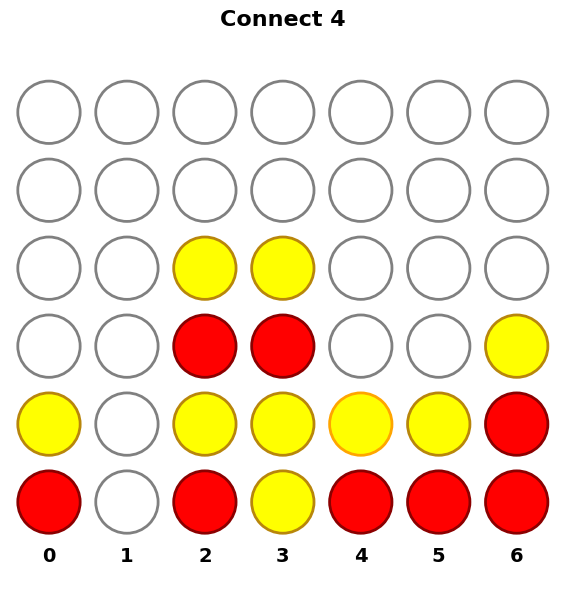

In [23]:
play_game()

## 10. Watch AI vs AI

Watch the Transformer play against the CNN!

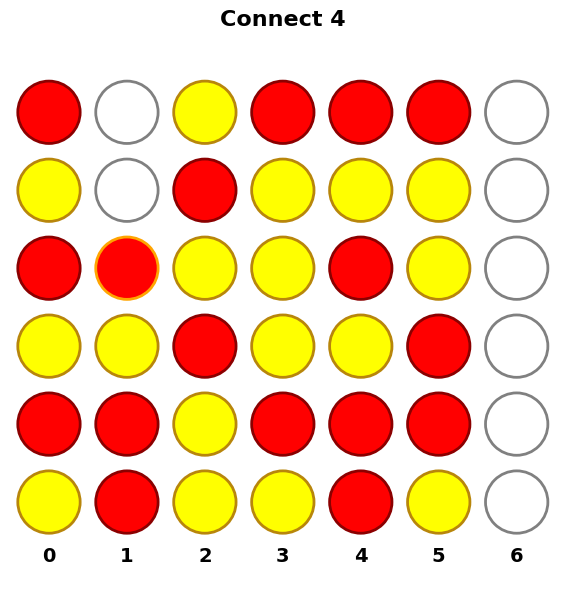


Move 34

****************************************
   CNN WINS in 34 moves!
****************************************


In [24]:
def ai_vs_ai(model1='transformer', model2='cnn', delay=1.0):
    """Watch two AIs play against each other."""

    if model1 == 'transformer' and transformer_model is None:
        print("Transformer model not loaded!")
        return
    if model1 == 'cnn' and cnn_model is None:
        print("CNN model not loaded!")
        return
    if model2 == 'transformer' and transformer_model is None:
        print("Transformer model not loaded!")
        return
    if model2 == 'cnn' and cnn_model is None:
        print("CNN model not loaded!")
        return

    print(f"\n{'='*50}")
    print(f"  {model1.upper()} (Yellow) vs {model2.upper()} (Red)")
    print(f"{'='*50}\n")

    board = np.zeros((6, 7))
    current_player = 'plus'
    last_move = None
    move_count = 0

    while True:
        clear_output(wait=True)
        display_board(board, last_move)
        print(f"\nMove {move_count}")

        # Check for win/draw
        if last_move is not None:
            winner = check_for_win(board, last_move)
            if winner != 'nobody':
                winning_model = model1 if winner == 'plus' else model2
                print(f"\n{'*'*40}")
                print(f"   {winning_model.upper()} WINS in {move_count} moves!")
                print(f"{'*'*40}")
                return winning_model

        if is_draw(board):
            print(f"\n{'*'*40}")
            print(f"   DRAW after {move_count} moves!")
            print(f"{'*'*40}")
            return 'draw'

        # Determine which model plays
        current_model = model1 if current_player == 'plus' else model2

        print(f"\n{current_model.upper()}'s turn...")

        col, policy, value = ai_move(board, current_player, current_model)

        print(f"Plays column {col} (confidence: {policy[col]*100:.1f}%)")

        board = update_board(board, current_player, col)
        last_move = col
        move_count += 1
        current_player = 'minus' if current_player == 'plus' else 'plus'

        time.sleep(delay)


# Watch the battle!
if transformer_model and cnn_model:
    ai_vs_ai('transformer', 'cnn', delay=1.5)
else:
    print("Need both models loaded for AI vs AI!")